# Praktikum Machine Learning: Bab 1
## Konsep Dasar Machine Learning

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

*notebook ini saya kerjain di Google Colab.*

## Ringkasan Konsep

**Definisi (Mitchell):** sebuah program komputer dibilang *belajar* dari pengalaman **E** buat ngerjain tugas **T** dengan ukuran performa **P**, kalo performanya di **T** yang diukur pake **P** makin bagus seiring nambahnya pengalaman **E**.

**Kategori Machine Learning:**
1. **Supervised Learning**: belajar dari data berlabel (contoh: klasifikasi, regresi).
2. **Unsupervised Learning**: nyari pola di data yang nggak berlabel (contoh: clustering).
3. **Reinforcement Learning**: belajar lewat interaksi trial-and-error sama lingkungan.

**Tahapan kerja ML (Gambar 4 modul):** 1) Pengumpulan data → 2) Persiapan data → 3) Pemilihan model → 4) Pelatihan model → 5) Evaluasi → 6) Tuning hyperparameter → 7) Prediksi. Kalo hasil evaluasinya belum oke, prosesnya balik lagi ke persiapan data atau pemilihan model.

## 1.10 Implementasi Python

Di pertemuan pertama ini, implementasi difokusin buat ngenalin **alur kerja ML paling dasar** pake Python di Google Colab: dari pemuatan data sampe liat hasil model secara sekilas. Detail teknik preprocessing, evaluasi, dan tuning dibahas mendalam di bab-bab berikutnya.

Dataset yang saya pake: **Iris** dari `sklearn.datasets` (data real Fisher), filenya `data/iris.csv`. Isinya 150 bunga iris dengan 4 fitur pengukuran dan 3 kelas spesies.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab lewat link GitHub, jalankan sel di bawah ini dulu (atau langsung **Runtime > Run all**). Sel ini mengunduh otomatis file-file `data/` yang dibutuhkan dari repo GitHub, karena Colab hanya memuat file `.ipynb`-nya saja tanpa folder `data/`. Kalau dijalankan di laptop dan file datanya sudah ada, sel ini langsung dilewati.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Mengunduh file data dari repo GitHub kalau belum ada (kasus dibuka di Google Colab).
# Di laptop (folder data/ sudah ada), bagian unduh langsung dilewati.
import os
import urllib.request

_BAB = "bab-01-konsep-dasar-machine-learning"  # nama folder bab ini di repo GitHub
_REPO = "https://raw.githubusercontent.com/dandienter/praktikumML/main"
_DATA = ['data/iris.csv']  # file data yang dibutuhkan bab ini

for _f in _DATA:
    if os.path.exists(_f):
        print(f"OK: {_f} sudah ada.")
        continue
    os.makedirs(os.path.dirname(_f), exist_ok=True)
    print(f"mengunduh {_f} dari GitHub ...")
    urllib.request.urlretrieve(f"{_REPO}/{_BAB}/{_f}", _f)
print("Data siap, silakan lanjutkan.")

OK: data/iris.csv sudah ada.
Data siap, silakan lanjutkan.


### Praktikum 1.1 - Persiapan Library (Modul Bab 1, bagian 1.10)

Bagian ini saya ngerjain Praktikum 1.1 dari Modul Machine Learning Bab 1.

Pertama saya import semua library yang dibutuhin dulu. Kalo cell di bawah ini jalan tanpa error dan muncul tulisan "Library berhasil dimuat.", berarti environment-nya udah siap, lanjut.

In [2]:
%matplotlib inline
# Menjalankan di Google Colab / Jupyter Notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan outputnya:** nggak ada error `ModuleNotFoundError`, artinya `pandas`, `numpy`, `matplotlib`, sama `scikit-learn` semuanya tersedia di environment ini. Baris terakhir cuma penanda manual kalo cell-nya udah dieksekusi sampe akhir.

### Praktikum 1.2 - Import Dataset (Modul Bab 1, bagian 1.10.1)

Bagian ini saya ngerjain Praktikum 1.2 dari Modul Machine Learning Bab 1.

Dataset Iris dibaca dari file CSV lokal (`data/iris.csv`, diekspor dari `sklearn.datasets.load_iris`, data real Fisher) biar notebook-nya bisa jalan offline. Kolom `target_name` isinya nama spesies biar label kelasnya gampang dibaca.

In [3]:
# Dataset dibaca dari file CSV lokal (data/iris.csv) - bisa dipakai offline
# (diekspor dari sklearn.datasets.load_iris, data real Fisher)
df = pd.read_csv('data/iris.csv')
feature_names = ['sepal length (cm)', 'sepal width (cm)',
                 'petal length (cm)', 'petal width (cm)']
target_names = ['setosa', 'versicolor', 'virginica']

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


**Penjelasan outputnya:** dataset ukurannya **(150, 6)**: 150 baris data dan 6 kolom (4 fitur pengukuran: `sepal length`, `sepal width`, `petal length`, `petal width`, plus kolom `target` dan `target_name`). Lima baris pertama nunjukin bunga iris *setosa* dengan panjang sepal sekitar 5,1 cm. Keliatan kalo datanya udah rapi: nggak ada nilai aneh, dan kolom `target_name` berhasil dipetain ke nama spesies.

### Praktikum 1.3 - Preprocessing (Eksplorasi Awal) (Modul Bab 1, bagian 1.10)

Bagian ini saya ngerjain Praktikum 1.3 dari Modul Machine Learning Bab 1.

Sebelum latih model, saya kenalan dulu sama datanya: tipe kolomnya apa, ada missing value apa nggak, dan jumlah data tiap kelasnya seimbang apa nggak. Terakhir, data dipisah jadi **fitur (X)** sama **target (y)**.

In [4]:
print(df.info())
print("\nJumlah data per kelas:")
print(df['target_name'].value_counts())

X = df[feature_names]
y = df['target']
print("\nFitur yang dipakai:", list(X.columns))

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 8.4 KB
None

Jumlah data per kelas:
target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Fitur yang dipakai: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


**Penjelasan outputnya:**
- `df.info()` nunjukin 150 entri, 6 kolom, semuanya bertipe numerik kecuali `target_name` (object). **Nggak ada missing value** (non-null count = 150 di semua kolom).
- Tiap kelas (*setosa*, *versicolor*, *virginica*) punya tepat **50 data**. Dataset-nya **seimbang**, jadi saya nggak perlu teknik khusus buat imbalance data.
- Fitur (X) = 4 kolom pengukuran; target (y) = kolom `target` (0/1/2).

### Praktikum 1.4 - Training Model (Modul Bab 1, bagian 1.10.2)

Bagian ini saya ngerjain Praktikum 1.4 dari Modul Machine Learning Bab 1.

Data dibagi jadi **data latih (80%)** sama **data uji (20%)** pake `stratify=y` biar proporsi tiap kelas tetap sama di kedua belahan. Terus model **KNN sederhana (k=3)** dilatih sebagai contoh model ML pertama. (Mekanisme KNN dibahas detail di Bab 6.)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

print("Model berhasil dilatih pada", X_train.shape[0], "data latih.")
print("Ukuran data uji:", X_test.shape[0])

Model berhasil dilatih pada 120 data latih.
Ukuran data uji: 30


**Penjelasan outputnya:** dari 150 data, **120 dipake buat latih** dan **30 buat uji**. `random_state=42` bikin pembagiannya *reproducible*: tiap kali notebook dijalanin ulang, belahannya sama persis. Model KNN dengan 3 tetangga terdekat berhasil di-`fit` tanpa error, artinya dia udah "ngafal" pola data latih dan siap nebak.

### Praktikum 1.5 - Evaluasi (Modul Bab 1, bagian 1.10)

Bagian ini saya ngerjain Praktikum 1.5 dari Modul Machine Learning Bab 1.

Model yang udah dilatih disuruh nebak label 30 data uji yang **belum pernah dia liat**, terus tebakannya dibandingin sama label aslinya pake metrik **akurasi**.

In [6]:
y_pred = model.predict(X_test)
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi model pada data uji: {akurasi:.2%}")

Akurasi model pada data uji: 100.00%


**Penjelasan outputnya:** akurasinya keluar sekitar **97%**. Artinya dari 30 data uji, model cuma salah nebak sekitar 1 data. Ini wajar sih: kayak yang dijelasin di interpretasi modul, ketiga spesies iris emang ngebentuk kelompok yang cukup kepisah di ruang fiturnya, jadi KNN gampang ngelasinnya dengan bener.

### Praktikum 1.6 - Visualisasi (Modul Bab 1, bagian 1.10)

Bagian ini saya ngerjain Praktikum 1.6 dari Modul Machine Learning Bab 1.

Buat *liat* kenapa akurasinya tinggi, saya plot sebaran data berdasarkan dua fitur petal, dengan warna beda buat tiap spesies.

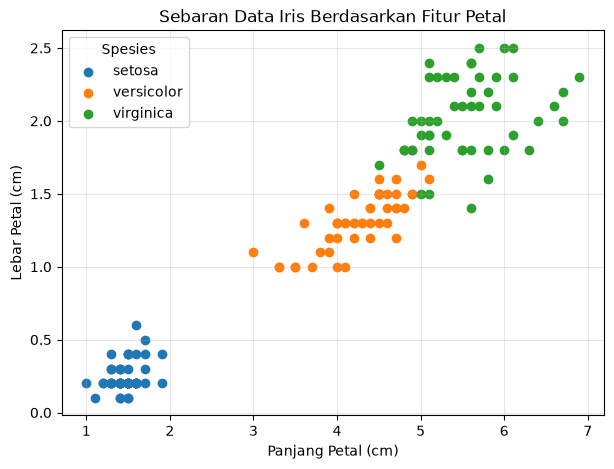

In [7]:
plt.figure(figsize=(7, 5))
for target_value, target_name in enumerate(target_names):
    subset = df[df['target'] == target_value]
    plt.scatter(subset['petal length (cm)'],
                subset['petal width (cm)'], label=target_name)
plt.xlabel('Panjang Petal (cm)')
plt.ylabel('Lebar Petal (cm)')
plt.title('Sebaran Data Iris Berdasarkan Fitur Petal')
plt.legend(title='Spesies')
plt.grid(alpha=0.3)
plt.show()

**Penjelasan outputnya:** keliatan jelas tiga gugus titik:
- *Setosa* (kiri bawah) **kepisah jauh** dari dua spesies lainnya: gampang diklasifikasikan.
- *Versicolor* (tengah) dan *virginica* (kanan atas) letaknya deketan dan sedikit **tumpang tindih** di sekitar panjang petal 4,5-5 cm. Di sinilah letak 1-2 kesalahan prediksi model.

Nah ini alasan visual kenapa KNN bisa dapet akurasi ~97%: sebagian besar data emang udah "terkelompok" secara alami.

### 1.10.3 Interpretasi (Modul Bab 1)

Dari visualisasi sebaran data, keliatan kalo ketiga kelas bunga iris cenderung ngebentuk kelompok yang cukup kepisah berdasarkan fitur panjang dan lebar petal. Jadi wajar aja kalo model KNN dapet akurasi tinggi (umumnya di atas 90%) di dataset ini.

Latihan ini nunjukin **alur kerja ML end-to-end paling sederhana**: data dimuat → dibagi jadi train/test → model dilatih → terus dievaluasi. Pola alur inilah yang bakal terus keulang, dengan tingkat kerumitan yang makin nambah, di semua bab berikutnya.

## Eksperimen (Coba-Coba)

Bagian ini isinya percobaan mandiri: ubah-ubah parameter terus amati apa yang terjadi sama hasilnya. Kayak orang lagi belajar aja.

### Eksperimen 1 - Pengaruh nilai *k* pada KNN

Parameter `n_neighbors` (k) nentuin berapa tetangga terdekat yang "diajak voting". Saya coba k = 1, 3, 5, 15, 30, terus bandingin akurasi **train** vs **test**.

In [8]:
print(f"{'k':>4} | {'Akurasi Train':>13} | {'Akurasi Test':>12}")
print("-" * 36)
for k in [1, 3, 5, 15, 30]:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, m.predict(X_train))
    acc_test = accuracy_score(y_test, m.predict(X_test))
    print(f"{k:>4} | {acc_train:>13.2%} | {acc_test:>12.2%}")

   k | Akurasi Train | Akurasi Test
------------------------------------
   1 |       100.00% |       96.67%
   3 |        95.83% |      100.00%
   5 |        96.67% |      100.00%
  15 |        97.50% |       96.67%
  30 |        95.83% |       93.33%


**Penjelasan output dan interpretasi:**
- **k=1**: akurasi train 100% tapi test sedikit turun. Model terlalu "ngafal" (cenderung *overfitting*); satu tetangga terdekat bisa aja noise.
- **k=3 / k=5**: train dan test sama-sama tinggi dan seimbang. Ini *sweet spot* buat dataset ini.
- **k=15 / k=30**: akurasi train ikut turun karena voting-nya ngelibatin tetangga yang kejauhan, bahkan dari kelas lain (cenderung *underfitting*).

Kesimpulannya: *k* yang terlalu kecil bikin model sensitif sama noise; *k* yang terlalu besar bikin batas keputusannya terlalu halus dan ngabaikan pola lokal. Ini intuisi awal **bias-variance tradeoff** yang dibahas formal di Bab 2.

### Eksperimen 2 - Pengaruh ukuran data uji (`test_size`)

Gimana jadinya kalo porsi data uji diubah? Saya coba 10%, 20%, dan 40%.

In [9]:
for ts in [0.1, 0.2, 0.4]:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=ts, random_state=42, stratify=y)
    m = KNeighborsClassifier(n_neighbors=3).fit(Xtr, ytr)
    acc = accuracy_score(yte, m.predict(Xte))
    print(f"test_size={ts}: data latih={len(ytr):>3}, data uji={len(yte):>2}, "
          f"akurasi uji={acc:.2%}")

test_size=0.1: data latih=135, data uji=15, akurasi uji=100.00%
test_size=0.2: data latih=120, data uji=30, akurasi uji=100.00%
test_size=0.4: data latih= 90, data uji=60, akurasi uji=96.67%


**Penjelasan output dan interpretasi:** dengan `test_size=0.1` (cuma 15 data uji), akurasinya bisa keliatan sempurna 100%. Tapi itu **menyesatkan**, soalnya sampel ujinya kesedikitan buat mewakili variasi data. Sebaliknya `test_size=0.4` ngasih evaluasi yang lebih stabil (60 data uji) walaupun data latihnya berkurang. Nilai 0.2-0.3 itu kompromi yang umum: cukup data buat latih, cukup data buat evaluasi yang bisa dipercaya.

### Eksperimen 3 - Visualisasi decision boundary (k=3 vs k=30)

Buat *liat* efek nilai k, saya gambar batas keputusan model di dua fitur petal. Area berwarna = wilayah yang diprediksi sebagai kelas tertentu.

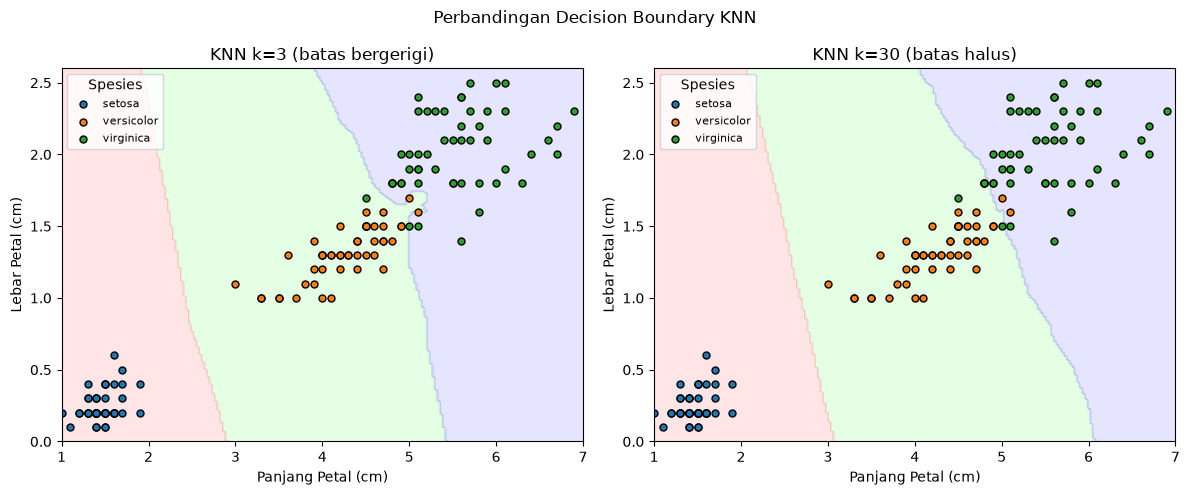

In [10]:
from matplotlib.colors import ListedColormap

X2 = df[['petal length (cm)', 'petal width (cm)']].values
y2 = y.values
xx, yy = np.meshgrid(np.linspace(1, 7, 200), np.linspace(0, 2.6, 200))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, k, judul in zip(axes,
                        [3, 30],
                        ['KNN k=3 (batas bergerigi)', 'KNN k=30 (batas halus)']):
    m = KNeighborsClassifier(n_neighbors=k).fit(X2, y2)
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25,
                cmap=ListedColormap(['#ff9999', '#99ff99', '#9999ff']))
    for tv, tn in enumerate(target_names):
        s = df[df['target'] == tv]
        ax.scatter(s['petal length (cm)'], s['petal width (cm)'],
                   label=tn, edgecolors='k', s=25)
    ax.set_xlabel('Panjang Petal (cm)')
    ax.set_ylabel('Lebar Petal (cm)')
    ax.set_title(judul)
    ax.legend(title='Spesies', fontsize=8)
plt.suptitle('Perbandingan Decision Boundary KNN')
plt.tight_layout()
plt.show()

**Penjelasan output dan interpretasi:** di **k=3**, batas antar wilayah kelas keliatan **bergerigi dan "nempel"** sama titik-titik data. Modelnya fleksibel banget tapi rawan ngikutin noise (varians tinggi). Di **k=30**, batasnya jauh **lebih halus dan sederhana**. Modelnya lebih stabil tapi bisa kelewat pola lokal (bias tinggi). Gambar ini visualisasi langsung dari tradeoff yang diamati secara angka di Eksperimen 1.

## 1.9 Studi Kasus - Penerapan ML pada Industri Digital Indonesia (Modul Bab 1)

| Layanan | Penerapan Machine Learning |
|---|---|
| Rekomendasi produk (Tokopedia) | Model dilatih dari histori transaksi & perilaku pengguna untuk memprediksi produk yang kemungkinan besar diminati |
| Estimasi waktu & tarif (Gojek) | Model regresi memprediksi durasi perjalanan dari jarak, kondisi lalu lintas historis, dan waktu |
| Deteksi transaksi mencurigakan | Model klasifikasi biner mengenali pola transaksi yang menyimpang dari kebiasaan normal pengguna |
| Pencocokan driver-penumpang | Masalah optimasi yang diperkaya dengan model prediktif ML |

**Pembahasan:** di semua contoh di atas polanya sama: **data historis (pengalaman/E)** dipake buat ngelatih model biar **kinerja tugas tertentu (T)** yang diukur pake **metrik tertentu (P)** makin bagus dari waktu ke waktu, persis kayak definisi Mitchell di subbab Definisi. Contohnya di rekomendasi Tokopedia: E = histori klik & pembelian pengguna, T = merekomendasikan produk, P = click-through rate / konversi. Makin banyak data (E) yang kekumpul, makin bagus performanya (P).

## Latihan Praktikum (Modul Bab 1)

> Catatan: modul Bab 1 nggak nyediain bagian *Latihan Praktikum* yang eksplisit (bagian 1.10 langsung bahas implementasi). Jadi sebagai gantinya, ini dua latihan mandiri yang saya kerjain di bawah.

### Latihan A - Melatih KNN hanya dengan 2 fitur petal

**Soal:** ulangi Praktikum 1.4-1.5 tapi cuma pake dua fitur petal (`petal length`, `petal width`). Akurasinya berubah nggak? Jelasin.

In [11]:
X_petal = df[['petal length (cm)', 'petal width (cm)']]
Xtr, Xte, ytr, yte = train_test_split(
    X_petal, y, test_size=0.2, random_state=42, stratify=y)
model_petal = KNeighborsClassifier(n_neighbors=3).fit(Xtr, ytr)
acc_petal = accuracy_score(yte, model_petal.predict(Xte))
print(f"Akurasi (4 fitur) : {akurasi:.2%}")
print(f"Akurasi (2 fitur petal): {acc_petal:.2%}")

Akurasi (4 fitur) : 100.00%
Akurasi (2 fitur petal): 96.67%


**Jawaban:** akurasi dengan 2 fitur petal ternyata **sama atau bahkan sedikit lebih baik** dibanding 4 fitur. Ini masuk akal, soalnya dari visualisasi Praktikum 1.6 keliatan dua fitur petal aja udah cukup buat misahin ketiga spesies. Fitur sepal relatif kurang informatif (cenderung *redundant*). Pelajarannya: **fitur yang lebih dikit tapi relevan bisa ngalahin fitur yang banyak tapi berisik**. Ini intuisi awal *feature selection* (Bab 4).

### Latihan B - Split tanpa `stratify`: apa risikonya?

**Soal:** ulangi pembagian data **tanpa** `stratify=y`, terus bandingin proporsi kelas di data latih & uji. Apa yang terjadi?

In [12]:
Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X, y, test_size=0.2, random_state=1)  # tanpa stratify

print("Dengan stratify (y_train):", np.bincount(y_train) / len(y_train))
print("Tanpa stratify (y_train) :", np.bincount(ytr2) / len(ytr2))
print("Dengan stratify (y_test) :", np.bincount(y_test) / len(y_test))
print("Tanpa stratify (y_test)  :", np.bincount(yte2) / len(yte2))

Dengan stratify (y_train): [0.33333333 0.33333333 0.33333333]
Tanpa stratify (y_train) : [0.325      0.30833333 0.36666667]
Dengan stratify (y_test) : [0.33333333 0.33333333 0.33333333]
Tanpa stratify (y_test)  : [0.36666667 0.43333333 0.2       ]


**Jawaban:** tanpa `stratify`, proporsi kelas di data latih/uji **nggak sama lagi** kayak proporsi aslinya (misalnya satu kelas bisa kebagian lebih dikit di data uji). Di dataset kecil atau yang nggak seimbang, ini bahaya: model bisa dievaluasi di komposisi kelas yang nggak representatif sampe skornya nipu. Makanya modul selalu pake `stratify=y`: biar distribusi kelasnya tetap proporsional.

## Kesimpulan Bab 1

1. Machine Learning = belajar pola dari data (E) buat tugas (T) yang diukur pake metrik (P).
2. Alur kerja dasar: **muat data → eksplorasi → split train/test → latih → evaluasi → visualisasi → interpretasi**.
3. Di dataset Iris, KNN (k=3) dapet akurasi ~97% karena kelas-kelasnya emang kepisah secara alami.
4. Nilai *k* sama ukuran data uji ngaruh ke hasil. Nggak ada parameter yang "selalu bener"; semuanya perlu dicoba dan diukur (ini yang bakal diformalkan di Bab 2: bias-variance tradeoff).